In [1]:
import os
import pandas as pd
import xgboost as xgb
import numpy as np

from pathlib import Path
import sys
sys.path.append("/home/alecacciatore/rolex/deep-nir/src/deep_nir/")

In [ ]:
file_path = "/home/alecacciatore/rolex/deep-nir/data/raw/Grain/08_CornGrain/08-MG_Rev489_RESULTS.xlsx"
sheet_name = "Temperature Variation"

with pd.ExcelFile(file_path) as xls:
    df = pd.read_excel(xls, sheet_name=sheet_name)

In [60]:
sample1 = [
    [55.6, 57.35, 55.5, 55.4, 1, 89.17, 88.69, 89.30, 89.48, 72.05, 72.12, 72.22, 72.06, 8.75, 9.22, 9.31, 9.41, 12.00, 12.01, 12.08, 11.96, 1.54, 1.59, 1.59, 1.55, 3.74, 3.49, 3.59, 3.69, 0.94, 1.31, 0.98, 0.96],
    [46.3, 46.55, 45.7, 45.2, 6, 89.02, 88.52, 89.20, 89.39, 72.43, 72.54, 72.65, 72.46, 8.66, 9.27, 9.34, 9.47, 11.72, 11.77, 11.85, 11.70, 1.52, 1.56, 1.59, 1.48, 3.91, 3.62, 3.71, 3.82, 0.98, 1.39, 1.01, 0.94],
    [39.4, 39.3, 39.35, 39.3, 11, 89.00, 88.49, 89.17, 89.43, 72.45, 72.56, 72.69, 72.49, 8.61, 9.23, 9.32, 9.45, 11.64, 11.70, 11.78, 11.65, 1.51, 1.53, 1.56, 1.48, 3.95, 3.65, 3.74, 3.84, 1.01, 1.44, 1.02, 0.95],
    [31.15, 31.6, 30.95, 30.5, 16, 89.03, 88.52, 89.21, 89.51, 72.43, 72.54, 72.72, 72.52, 8.54, 9.11, 9.24, 9.39, 11.51, 11.56, 11.68, 11.56, 1.52, 1.51, 1.54, 1.51, 3.98, 3.69, 3.77, 3.86, 1.10, 1.51, 1.06, 0.98],
    [24.2, 24.2, 24.1, 24, 21, 89.01, 88.75, 89.31, 89.61, 72.33, 72.41, 72.70, 72.44, 8.46, 9.05, 9.07, 9.35, 11.39, 11.47, 11.54, 11.48, 1.54, 1.53, 1.54, 1.54, 4.01, 3.70, 3.81, 3.87, 1.20, 1.60, 1.13, 1.02],
    [19.7, 19.75, 19.55, 19.5, 26, 89.05, 88.85, 89.30, 89.62, 72.13, 72.23, 72.54, 72.31, 8.47, 8.98, 9.07, 9.30, 11.32, 11.39, 11.51, 11.41, 1.54, 1.55, 1.55, 1.57, 4.03, 3.70, 3.81, 3.88, 1.32, 1.69, 1.26, 1.10],
    [11.6, 11.5, 11.85, 11.9, 31, 89.10, 89.03, 89.25, 89.73, 71.88, 71.98, 72.34, 72.16, 8.42, 8.93, 8.97, 9.20, 11.21, 11.28, 11.38, 11.29, 1.50, 1.56, 1.55, 1.59, 4.02, 3.72, 3.81, 3.86, 1.46, 1.76, 1.36, 1.18]
]

sample2 = [
    [56.25, 57.05, 56.1, 56, 2, 85.12, 84.24, 85.21, 85.31, 71.38, 71.55, 71.61, 71.65, 8.92, 9.12, 9.24, 9.18, 11.68, 11.60, 11.66, 11.59, 1.62, 1.63, 1.62, 1.63, 3.40, 3.29, 3.30, 3.34, 1.66, 1.95, 1.50, 1.28],
    [49.5, 49.4, 49.45, 49.15, 7, 84.72, 83.94, 84.84, 84.85, 71.77, 72.00, 72.03, 71.97, 9.11, 9.33, 9.43, 9.34, 11.68, 11.55, 11.72, 11.62, 1.70, 1.74, 1.74, 1.73, 3.33, 3.22, 3.23, 3.28, 1.15, 1.55, 1.03, 0.90],
    [42.15, 42.65, 42.1, 41.95, 12, 84.89, 84.02, 84.97, 85.07, 71.83, 72.06, 72.06, 72.07, 9.12, 9.40, 9.51, 9.49, 11.58, 11.49, 11.64, 11.51, 1.64, 1.73, 1.73, 1.73, 3.36, 3.23, 3.26, 3.31, 0.99, 1.46, 0.97, 0.83],
    [32.65, 32.9, 32.55, 32.35, 17, 85.11, 84.27, 85.23, 85.40, 71.96, 72.13, 72.18, 72.20, 8.99, 9.37, 9.48, 9.51, 11.29, 11.27, 11.38, 11.27, 1.51, 1.64, 1.63, 1.65, 3.58, 3.39, 3.47, 3.54, 1.03, 1.52, 1.05, 0.90],
    [24.3, 24.3, 24.3, 24.3, 22, 85.44, 84.83, 85.69, 85.81, 72.05, 72.11, 72.24, 72.17, 8.80, 9.34, 9.45, 9.57, 11.03, 11.04, 11.16, 11.06, 1.33, 1.48, 1.45, 1.43, 3.92, 3.68, 3.77, 3.87, 1.26, 1.71, 1.25, 1.15],
    [20.5, 20.75, 20.55, 20.6, 27, 85.59, 85.12, 85.79, 86.12, 71.90, 71.93, 72.15, 72.11, 8.72, 9.26, 9.39, 9.51, 10.92, 10.94, 11.09, 11.01, 1.34, 1.47, 1.42, 1.41, 4.00, 3.72, 3.82, 3.92, 1.29, 1.74, 1.28, 1.13],
    [12.4, 12.4, 12.5, 12.85, 32, 85.74, 85.33, 85.90, 86.26, 71.78, 71.82, 72.06, 71.98, 8.65, 9.23, 9.33, 9.52, 10.82, 10.87, 10.98, 10.91, 1.38, 1.49, 1.42, 1.42, 4.06, 3.75, 3.87, 3.98, 1.36, 1.81, 1.34, 1.17]
]

In [61]:
sensors = ["EvoNIR MS", "249063", "249062", "249061"]
labels = ["T", "DM", "Starch DM Base", "Protein DM Base", "NDF DM Base", "Ash DM Base", "C.Fat DM Base", "C.Fiber DM Base"]

sample1_dict, sample2_dict = {}, {}

for id in sample1:
    id_scan = id[4]
    id.pop(4)
    
    id_dict = {}
    for i, label in enumerate(labels):
        id_dict[label] = {sensor: id[i * len(sensors) + j] for j, sensor in enumerate(sensors)}
    
    sample1_dict[id_scan] = id_dict

for id in sample2:
    id_scan = id[4]
    id.pop(4)
    
    id_dict = {}
    for i, label in enumerate(labels):
        id_dict[label] = {sensor: id[i * len(sensors) + j] for j, sensor in enumerate(sensors)}
    
    sample2_dict[id_scan] = id_dict

In [62]:
input_path = "/home/alecacciatore/rolex/deep-nir/data/raw/Grain/08_CornGrain/Temperatura"

inputs = {}
for txt in os.listdir(input_path):
    if txt.endswith(".txt"):
        with open(os.path.join(input_path, txt), "r") as f:
            lines = f.readlines()
            # tab separated values, convert to float and store in dictionary
            inputs[txt.split(".")[0]] = {}
            for line in lines:
                line_tab = line.strip().split("\t")
                inputs[txt.split(".")[0]][int(line_tab[0])] = [float(value) for value in line_tab[1:]]

In [55]:
# load xgboost model
from joblib import load

model_path = "/home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/"

# Carica il modello
models = {}
for model in os.listdir(model_path):
    if model.endswith(".joblib"):
        model_name = model.split("_")[0]
        model_full_path = os.path.join(model_path, model)
        print(f"Loading model: {model_name} from {model_full_path}")
        loaded_model = load(model_full_path)
        models[model_name] = loaded_model

Loading model: ADF from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/ADF_xgb_regr.joblib
Loading model: Crude Fib. from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/Crude Fib._xgb_regr.joblib
Loading model: Crude Fat from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/Crude Fat_xgb_regr.joblib
Loading model: Ash from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/Ash_xgb_regr.joblib
Loading model: Starch from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/Starch_xgb_regr.joblib
Loading model: NDF from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/NDF_xgb_regr.joblib
Loading model: Protein from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_models/Protein_xgb_regr.joblib
Loading model: DM from /home/alecacciatore/rolex/deep-nir/src/deep_nir/VRAI/outputs/pretrained_mode

In [94]:
# test on [:7] and then on [7:] separately 
# for each group, compare results (compute mean and std) and print them out

sample1_keys = list(sample1_dict.keys())
sample2_keys = list(sample2_dict.keys())

preds_1, preds_2 = {}, {}
for sensor_id, sensor in enumerate(inputs.keys()):
    preds_1[sensor] = {}
    preds_2[sensor] = {}
    for idx, id_scan in enumerate(inputs[sensor].keys()):
        if idx < 7:
            preds_1[sensor][id_scan] = {}
            sample1_T_list = list(sample1_dict[sample1_keys[idx]]['T'].keys())
            print(f"Sensor: {sensor}, ID scan: {id_scan} @ Temperature: {sample1_dict[sample1_keys[idx]]['T'][sample1_T_list[0]]}°C")
            
            input_act = inputs[sensor][id_scan]
            
            for model in models.keys():
                input_values = np.array(input_act).reshape(1, -1)
                prediction = models[model].predict(input_values)
                preds_1[sensor][id_scan][model] = prediction[0]
                print(f"Model: {model}, Prediction: {prediction[0]}")

        else:
            preds_2[sensor][id_scan] = {}
            sample2_T_list = list(sample2_dict[sample2_keys[idx-7]]['T'].keys())
            print(f"Sensor: {sensor}, ID scan: {id_scan} @ Temperature: {sample2_dict[sample2_keys[idx-7]]['T'][sample2_T_list[0]]}°C")
            
            input_act = inputs[sensor][id_scan]

            for model in models.keys():
                input_values = np.array(input_act).reshape(1, -1)
                prediction = models[model].predict(input_values)
                preds_2[sensor][id_scan][model] = prediction[0]
                print(f"Model: {model}, Prediction: {prediction[0]}")

Sensor: 1_MASTER_EVO, ID scan: 1 @ Temperature: 55.6°C
Model: ADF, Prediction: 6.985924243927002
Model: Crude Fib., Prediction: 2.9359591007232666
Model: Crude Fat, Prediction: 11.858238220214844
Model: Ash, Prediction: 1.875303864479065
Model: Starch, Prediction: 72.79228973388672
Model: NDF, Prediction: 10.109678268432617
Model: Protein, Prediction: 25.588722229003906
Model: DM, Prediction: 85.4027099609375
Sensor: 1_MASTER_EVO, ID scan: 4 @ Temperature: 46.3°C
Model: ADF, Prediction: 7.194437503814697
Model: Crude Fib., Prediction: 1.6281237602233887
Model: Crude Fat, Prediction: 8.763387680053711
Model: Ash, Prediction: 1.7871206998825073
Model: Starch, Prediction: 72.91270446777344
Model: NDF, Prediction: 9.935379981994629
Model: Protein, Prediction: 19.68896484375
Model: DM, Prediction: 86.2579116821289
Sensor: 1_MASTER_EVO, ID scan: 7 @ Temperature: 39.4°C
Model: ADF, Prediction: 7.109831809997559
Model: Crude Fib., Prediction: 1.5567340850830078
Model: Crude Fat, Prediction: 9.

In [104]:
sensor_list = list(preds_1.keys())

for sensor in range(len(sensor_list)):
    for id in preds_1[sensor_list[sensor]].keys():
        print(f"Sensor: {sensor_list[sensor]}, ID scan: {id}")
        for model in models.keys():
            model_preds = [preds_1[sensor][id][model] for sensor in sensor_list]
            mean_pred = np.mean(model_preds)
            std_pred = np.std(model_preds)
            print(f"\tModel: {model}, Mean Prediction: {mean_pred}, Std Dev: {std_pred}")

Sensor: 1_MASTER_EVO, ID scan: 1
	Model: ADF, Mean Prediction: 7.119113922119141, Std Dev: 0.08608905971050262
	Model: Crude Fib., Mean Prediction: 3.082512378692627, Std Dev: 0.08494674414396286
	Model: Crude Fat, Mean Prediction: 12.771784782409668, Std Dev: 0.6525490880012512
	Model: Ash, Mean Prediction: 2.0109634399414062, Std Dev: 0.07948210835456848
	Model: Starch, Mean Prediction: 72.94854736328125, Std Dev: 0.12419510632753372
	Model: NDF, Mean Prediction: 10.340571403503418, Std Dev: 0.14267857372760773
	Model: Protein, Mean Prediction: 25.247163772583008, Std Dev: 0.5522248148918152
	Model: DM, Mean Prediction: 85.08412170410156, Std Dev: 0.25310230255126953
Sensor: 1_MASTER_EVO, ID scan: 4
	Model: ADF, Mean Prediction: 7.130749702453613, Std Dev: 0.06642667949199677
	Model: Crude Fib., Mean Prediction: 2.3348543643951416, Std Dev: 0.6261531710624695
	Model: Crude Fat, Mean Prediction: 13.278999328613281, Std Dev: 2.62310528755188
	Model: Ash, Mean Prediction: 1.829291105270

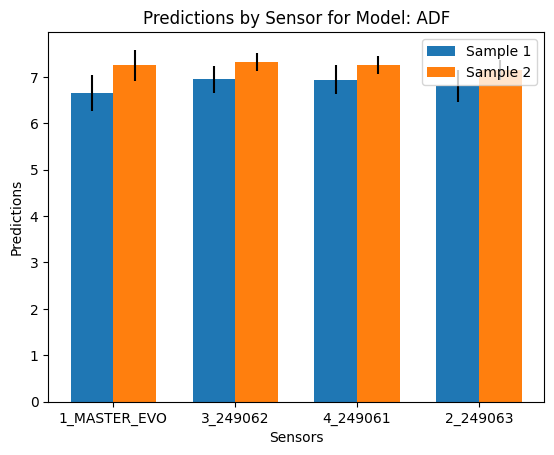

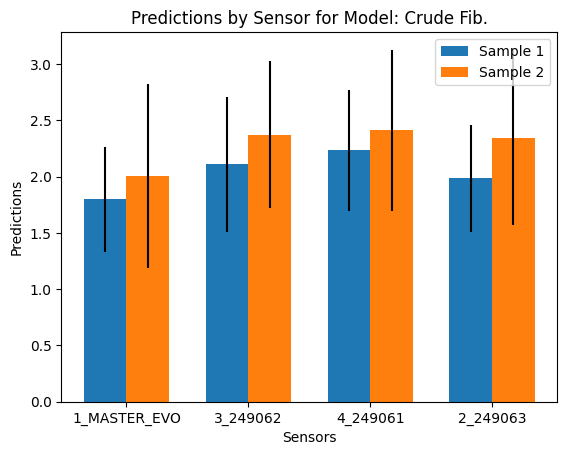

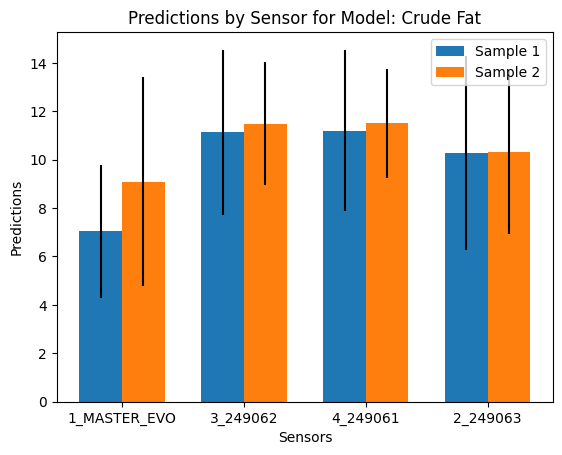

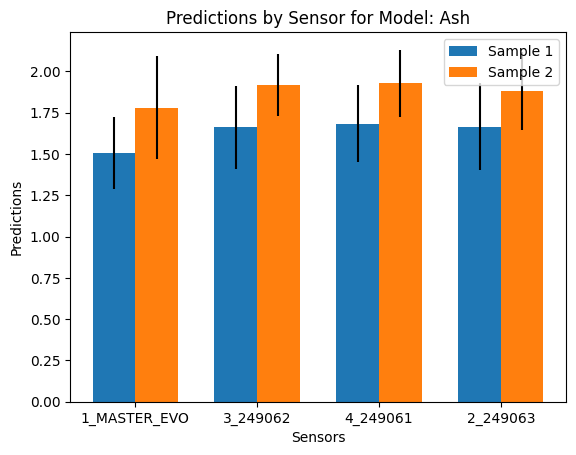

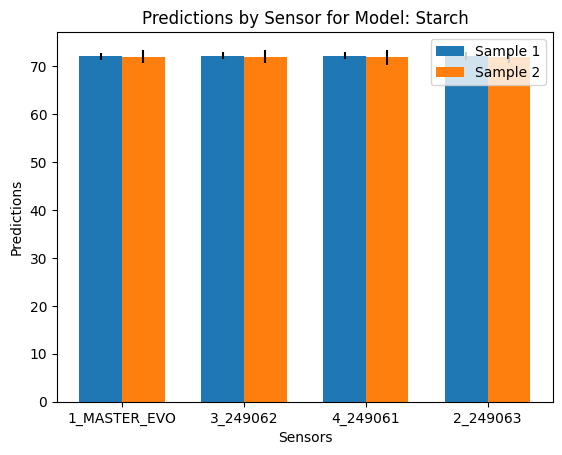

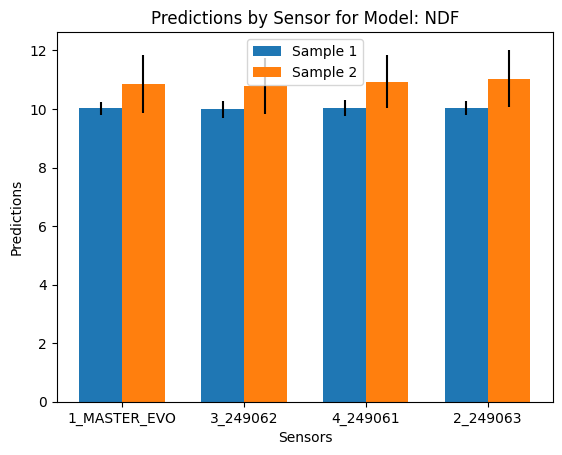

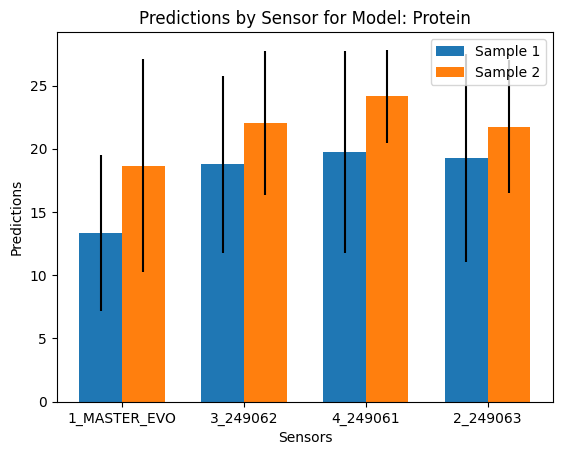

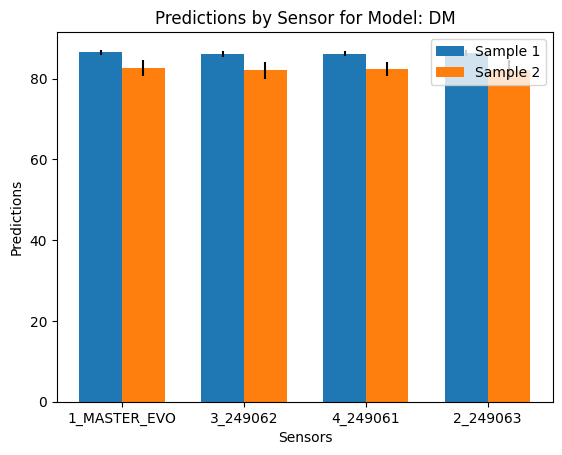

In [122]:
import matplotlib.pyplot as plt

# plot distribution of predictions for each model and each sensor, with error bars representing the std deviation
for model in models.keys():
    means_1, stds_1, means_2, stds_2 = [], [], [], []
    for sensor in sensor_list:
        model_preds_1 = [preds_1[sensor][id][model] for id in preds_1[sensor].keys()]
        model_preds_2 = [preds_2[sensor][id][model] for id in preds_2[sensor].keys()]
        means_1.append(np.mean(model_preds_1))
        stds_1.append(np.std(model_preds_1))
        means_2.append(np.mean(model_preds_2))
        stds_2.append(np.std(model_preds_2))
    
    x = np.arange(len(sensor_list))
    width = 0.35
    
    plt.bar(x - width/2, means_1, width, yerr=stds_1, label='Sample 1')
    plt.bar(x + width/2, means_2, width, yerr=stds_2, label='Sample 2')
    
    plt.xlabel('Sensors')
    plt.ylabel('Predictions')
    plt.title(f'Predictions by Sensor for Model: {model}')
    plt.xticks(x, sensor_list)
    plt.legend()
    plt.show()

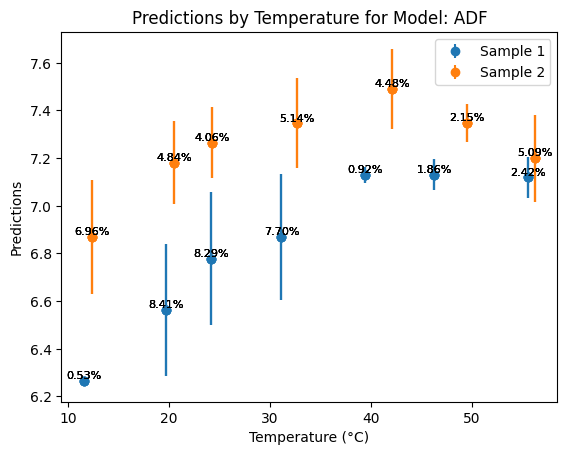

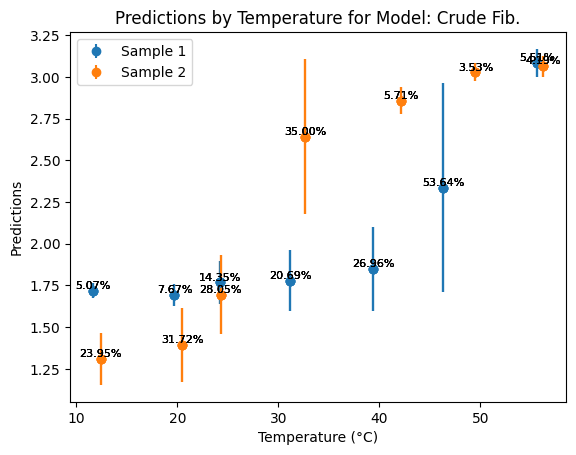

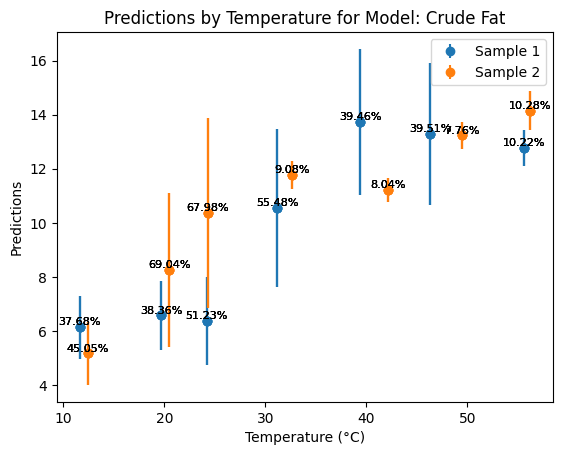

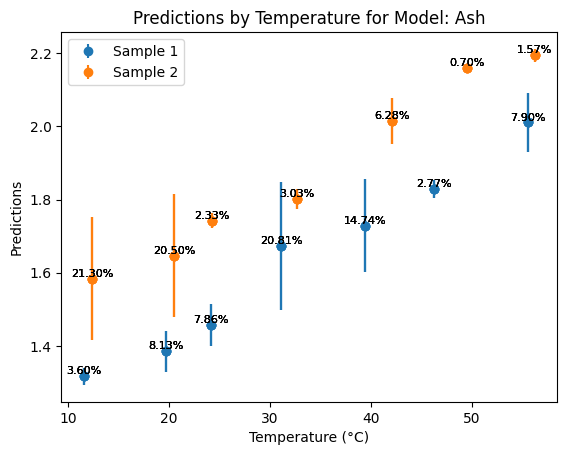

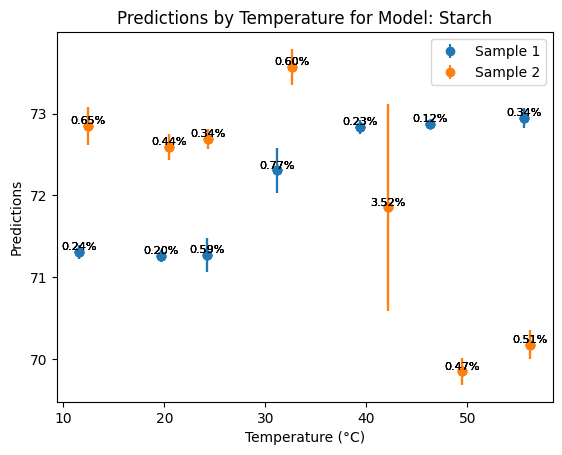

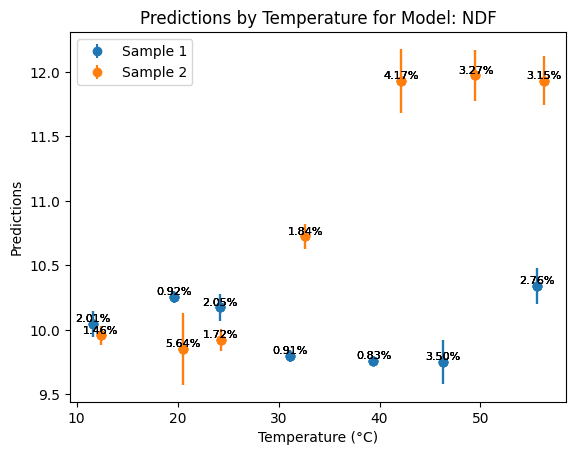

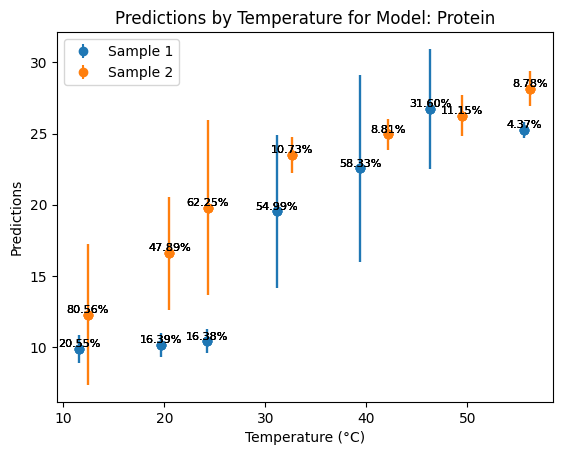

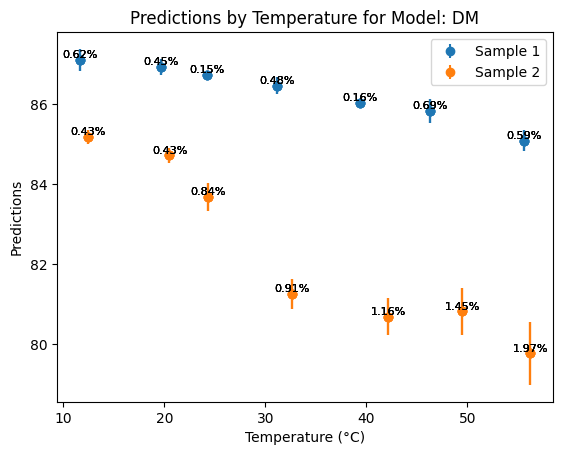

In [120]:
# plot another type of plot, with x axis being the temperature and y axis being the predictions, with error bars representing the std deviation
for model in models.keys():
    temps_1, preds_1_mean, preds_1_std = [], [], []
    temps_2, preds_2_mean, preds_2_std = [], [], []
    
    for sensor in sensor_list:
        for id_pos, id in enumerate(preds_1[sensor].keys()):
            sample1_T_list = list(sample1_dict[sample1_keys[id_pos]]['T'].keys())
            temp = sample1_dict[sample1_keys[id_pos]]['T'][sample1_T_list[0]]
            model_preds = [preds_1[sensor][id][model] for sensor in sensor_list]
            temps_1.append(temp)
            preds_1_mean.append(np.mean(model_preds))
            preds_1_std.append(np.std(model_preds))

        for id_pos, id in enumerate(preds_2[sensor].keys()):
            sample2_T_list = list(sample2_dict[sample2_keys[id_pos]]['T'].keys())
            temp = sample2_dict[sample2_keys[id_pos]]['T'][sample2_T_list[0]]
            model_preds = [preds_2[sensor][id][model] for sensor in sensor_list]
            temps_2.append(temp)
            preds_2_mean.append(np.mean(model_preds))
            preds_2_std.append(np.std(model_preds))
    
    plt.errorbar(temps_1, preds_1_mean, yerr=preds_1_std, fmt='o', label='Sample 1')
    plt.errorbar(temps_2, preds_2_mean, yerr=preds_2_std, fmt='o', label='Sample 2')

    # add min vs max variation as percentage of the mean prediction as text on the plot
    for i in range(len(temps_1)):
        min_pred = preds_1_mean[i] - preds_1_std[i]
        max_pred = preds_1_mean[i] + preds_1_std[i]
        variation = (max_pred - min_pred) / preds_1_mean[i] * 100
        plt.text(temps_1[i], preds_1_mean[i], f'{variation:.2f}%', fontsize=8, ha='center', va='bottom')
        
    for i in range(len(temps_2)):
        min_pred = preds_2_mean[i] - preds_2_std[i]
        max_pred = preds_2_mean[i] + preds_2_std[i]
        variation = (max_pred - min_pred) / preds_2_mean[i] * 100
        plt.text(temps_2[i], preds_2_mean[i], f'{variation:.2f}%', fontsize=8, ha='center', va='bottom')
  
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Predictions')
    plt.title(f'Predictions by Temperature for Model: {model}')
    plt.legend()
    plt.show()